# [2022] Barometric Pressure Data Preparation
JOHN CRAMBLITT | 3/2/2024

This notebook facilitates preparation of the barometric pressure time series used for compensating the unvented Levelogger time series.

When possible, the analyst will first inspect available Barologger time series. In order to use the Barologger time series for the compensation step, there should be no obvious erroneous segments in the time series and, for the sake of consistency when completing the subsequent Levelogger post-processing, the time series must span the Levelogger time series for all sites. That is, the first Barologger data point must be before the first Levelogger data point (across all sites) and the last Barologger data point must be after the last Levelogger data point (for all sites.

If no such Barologger time series exists, a different baromertric time series should be used. This notebook shows how to use NCAR reanalysis data to get a time series for surface pressure.

Once all steps have been completed, a barometric pressure time series will be ready to load for the compensation step.

## Import Relevant Libraries
**Analyst TODO**: Nothing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join('..', '..', 'src')))

import config
import level_baro_utils

sys.path.remove(os.path.abspath(os.path.join('..', '..', 'src')))

## Inspect Available Barologger Data
**Analyst TODO**: Inspect each available Barologger time series
* assign a string (format 'YYYY') representing the collection year of the data to the variable `collection_year`
* assign a string (format 'YY/YY') representing the span in years of the data to the variable `span`

Then, for each available time series
1. create a new Markdown cell, label ### Baro Sample X, where X is the sample number
2. make a copy of the code cell containing the site information and call to the `inspect_baro` function
3. assign a string representing the short name of the site to the variable `sitename_short`. Note, this is the name of the site contained in the filename (no spaces, may have abbreviations)
4. assign a string representing the long name of the site to the variable `long_short`. Note, this is the more "readable" name of the site (spaces, no abbreviations) used for plotting
5. Run the code cell, inspect the plot, and verify the time series spans all Levelogger time series. That is, the first Barologger data point must be before the first Levelogger data point (across all sites) and the last Barologger data point must be after the last Levelogger data point (for all sites.

If no valid Barologger time series exists, move on the next section: Prepare NCAR Reanalysis Pressure Data as Needed

In [2]:
def inspect_baro(sitename_short, sitename_long, site_info):
    baro_path = os.path.join('..', 'data', 'normalized_raw', f'baro_{sitename_short}_{collection_year}.csv')

    baro_df = level_baro_utils.load_normalized_solinst_data(baro_path)
    level_baro_utils.plot_solinst_pressure_temp(baro_df, site_info, sensor_type='baro')

    start_date = baro_df.index[0]
    end_date = baro_df.index[-1]

    print(f'Time Series Start: {start_date}')
    print(f'Time Series End: {end_date}')
    
    return baro_df

In [ ]:
# TODO: specift collection year and span
# e.g.
# collection_year = '2019'
# span = '18/19'

collection_year = '2022'
span = '21/22'

### Baro Sample 1

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\level_baro_utils.py:84: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(fn, index_col=0, parse_dates=[0], infer_datetime_format=True)


Time Series Start: 2021-08-13 13:00:00
Time Series End: 2022-09-08 15:30:00


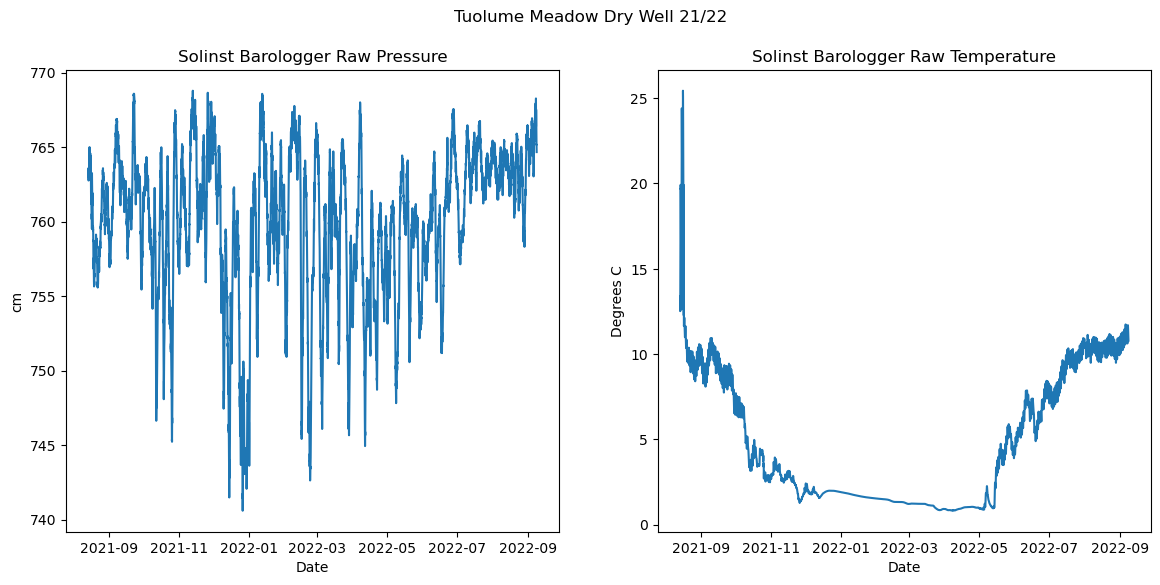

In [4]:
# TODO: copy this code cell for each sample
# e.g.
# sitename_short = 'ConnessCrk'
# sitename_long = 'Conness Creek'

sitename_short = 'TuolumneMeadow'
sitename_long = 'Tuolume Meadow Dry Well'
site_info = {'sitecode':-1,
             'site':sitename_long,
             'collection_year':collection_year,
             'span':span}

baro_sample1_df = inspect_baro(sitename_short, sitename_long, site_info)

**Analyst Notes:** Tuolumne Meadows Barologger was flooded during winter --  data should not be used. 

### Baro Sample 2

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\level_baro_utils.py:84: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(fn, index_col=0, parse_dates=[0], infer_datetime_format=True)


Time Series Start: 2021-08-11 00:00:00
Time Series End: 2022-08-01 21:30:00


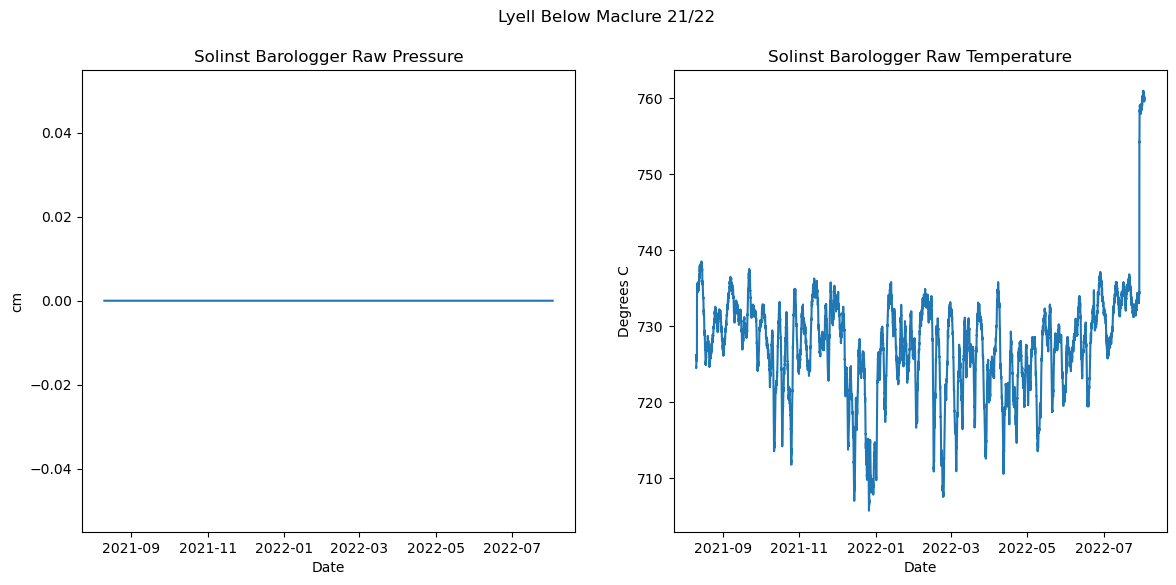

In [5]:
sitename_short = 'LyellBlwMaclure'
sitename_long = 'Lyell Below Maclure'
site_info = {'sitecode':-1,
             'site':sitename_long,
             'collection_year':collection_year,
             'span':span}

baro_sample2_df = inspect_baro(sitename_short, sitename_long, site_info)

### Baro Sample 3

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\level_baro_utils.py:84: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(fn, index_col=0, parse_dates=[0], infer_datetime_format=True)


Time Series Start: 2021-07-01 00:00:00
Time Series End: 2022-09-30 00:00:00


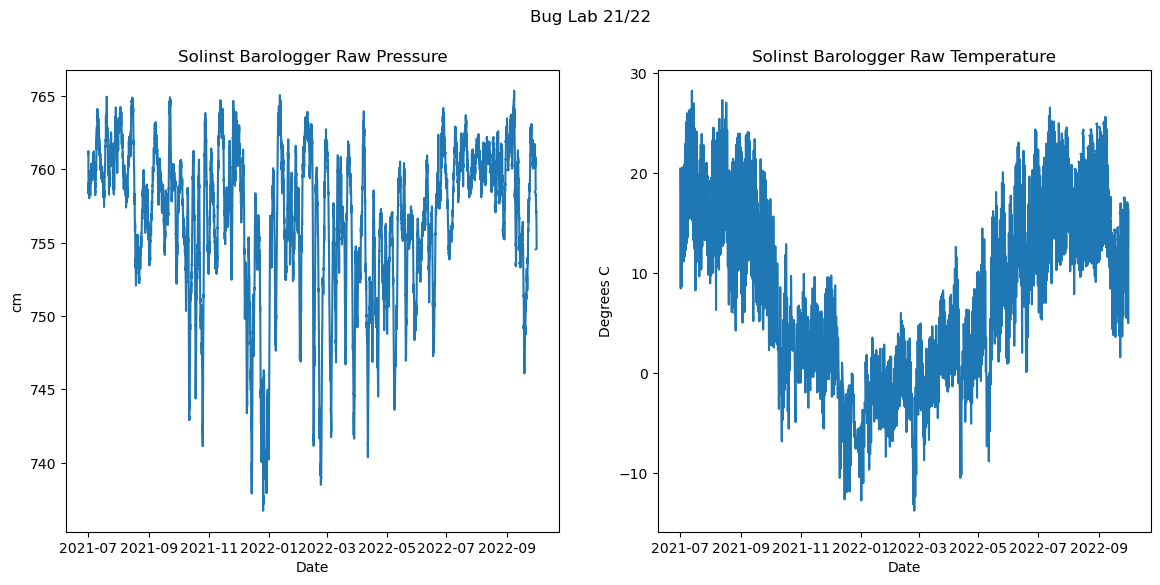

In [6]:
sitename_short = 'BugLab'
sitename_long = 'Bug Lab'
site_info = {'sitecode':-1,
             'site':sitename_long,
             'collection_year':collection_year,
             'span':span}

baro_sample3_df = inspect_baro(sitename_short, sitename_long, site_info)

**Analyst Notes:** Bug Lab raw baro data looks good and spans entire time series.

## Prepare NCAR Reanalysis Pressure Data as Needed
**Analyst TODO**: 

For previous analysis, we used NCEP-NCAR Reanalysis data (https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html). If using another data source, the workflow provided below may need to be tweaked. 

Begin by downloading data for 3 variables: surface pressure, surface temperature, and geopotential height. Choose the time series with highest temporal resolution (for NCEP_NCAR Reanalysis, 4x daily). Since the levelogger data spans two calendar years, download the complete reanalysis time series for both years of interest. Create a new subdirectory in the /data directory called /ncar_reanalysis, and move the downloaded files to this directory.

### Load Data
**Analyst TODO**: Replace the bracketed segments of the paths with the correct file name.

In [7]:
# surface pressure
p1_path = '../data/ncar_reanalysis/pres.sfc.2021.nc'
p2_path = '../data/ncar_reanalysis/pres.sfc.2022.nc'

# surface temperature (all lat/lon)
st1_path = '../data/ncar_reanalysis/air.sig995.2021.nc'
st2_path = '../data/ncar_reanalysis/air.sig995.2022.nc'

# height
hgt_path = '../data/ncar_reanalysis/hgt.sfc.nc'

In [8]:
p1_global_ds = xr.open_dataset(p1_path)
p2_global_ds = xr.open_dataset(p2_path)

st1_global_ds = xr.open_dataset(st1_path)
st2_global_ds = xr.open_dataset(st2_path)

hgt_ds = xr.open_dataset(hgt_path)

In [27]:
p1_global_ds.time

<xarray.DataArray 'time' (time: 1460)> Size: 12kB
array(['2021-01-01T00:00:00.000000000', '2021-01-01T06:00:00.000000000',
       '2021-01-01T12:00:00.000000000', ..., '2021-12-31T06:00:00.000000000',
       '2021-12-31T12:00:00.000000000', '2021-12-31T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 12kB 2021-01-01 ... 2021-12-31T18:00:00
Attributes:
    long_name:      Time
    delta_t:        0000-00-00 06:00:00
    standard_name:  time
    axis:           T
    actual_range:   [1937256. 1946010.]

### Isolate Desired Lat Long
**Analyst TODO**: Nothing

In [9]:
p1 = p1_global_ds.pres.sel(lat=config.NCAR_TUM_LAT, lon=config.NCAR_TUM_LON)
p2 = p2_global_ds.pres.sel(lat=config.NCAR_TUM_LAT, lon=config.NCAR_TUM_LON)

st1 = st1_global_ds.air.sel(lat=config.NCAR_TUM_LAT, lon=config.NCAR_TUM_LON)
st2 = st2_global_ds.air.sel(lat=config.NCAR_TUM_LAT, lon=config.NCAR_TUM_LON)

hgt = hgt_ds.hgt.sel(lat=config.NCAR_TUM_LAT, lon=config.NCAR_TUM_LON)

### Merge Each Time Dependent Variable into Single Time Series
**Analyst TODO**: Inspect the side by side and merged time series plots. Verify everything looks reasonable.

#### Pressure

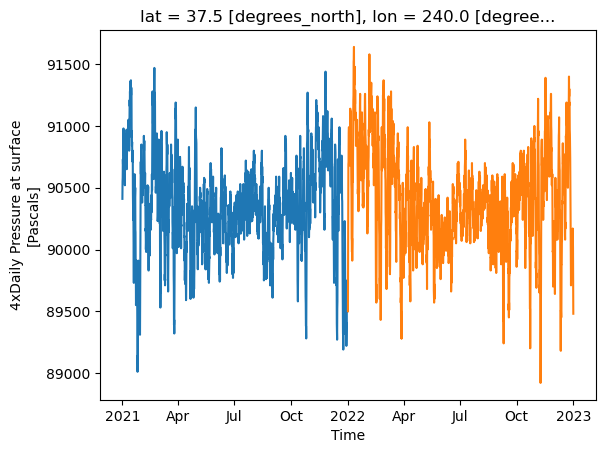

In [10]:
p1.plot()
p2.plot()

In [11]:
p1p2 = xr.merge([p1, p2])
p1p2.pres

<xarray.DataArray 'pres' (time: 2920)> Size: 12kB
array([90410., 90550., 90580., ..., 90020., 89730., 89480.], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2021-01-01 ... 2022-12-31T18:00:00
    lat      float32 4B 37.5
    lon      float32 4B 240.0
Attributes:
    long_name:     4xDaily Pressure at surface
    units:         Pascals
    precision:     -1
    GRIB_id:       1
    GRIB_name:     PRES
    var_desc:      Pressure
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    valid_range:   [ 40000. 115000.]
    dataset:       NCEP Reanalysis
    actual_range:  [ 49540. 109580.]

Text(0, 0.5, 'Pascals')

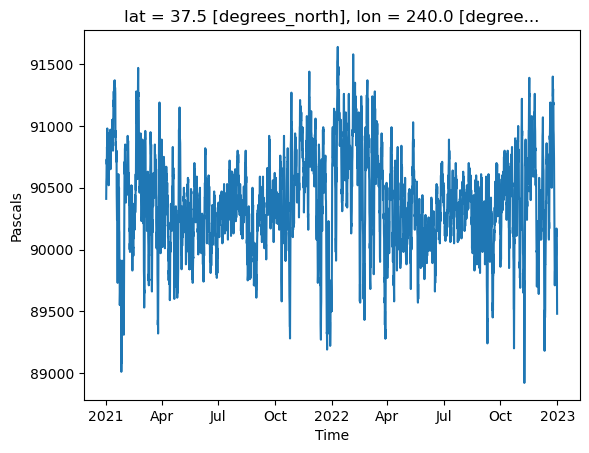

In [12]:
p1p2.pres.plot()
plt.ylabel('Pascals')

#### Air Temp

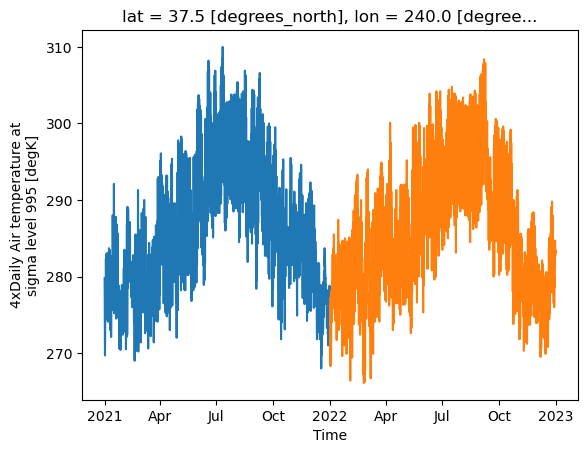

In [14]:
st1.plot()
st2.plot()

In [15]:
st1st2 = xr.merge([st1, st2])

Text(0, 0.5, 'K')

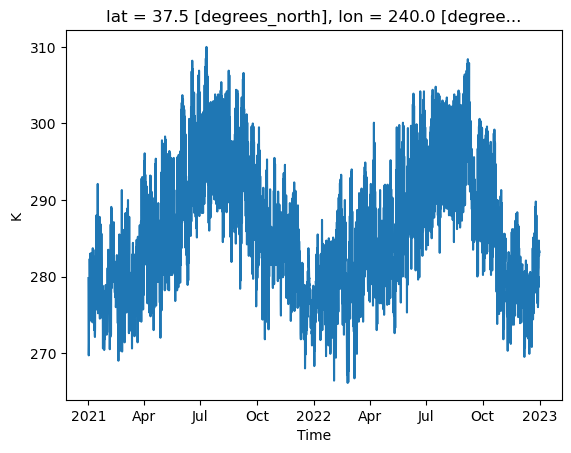

In [16]:
st1st2.air.plot()
plt.ylabel('K')

Analyst Notes: NCEP reanalysis surface temperature and pressure both look reasonable for 2021-2022.

### Use Hypsometric Equation to Solve for Pressure at Tuolumne Elevation
Here we apply the hypsometric equation using the surface pressure, surface temperature, and geopotential height (the height of the surface) to compute the surface pressure for Tuolumne's elevation. Note that we approximate the virtual temperature with the actual temperature and the surface elevation with the geopotential height. We also assume a lapse rate of -6.5 C/km to compute the temperature in the middle of the column.

**Analyst TODO**: Nothing

In [35]:
h_tum = config.TUM_ELEVATION  # h2, m
h_pixel = hgt.values[0]  # h1, m
h = h_tum - h_pixel  # h2 - h1, m
R = 287.052874  # specific gas constant for dry air, J K^-1 kg^-1
g = 9.80665  # m / s^2
P1 = p1p2
lapse_rate = -6.5 # C/km
T = st1st2.air + (lapse_rate * (h / 10**3) / 2)

P2 = P1 * np.exp((-1 * h * g) / (R * T))

P2

<xarray.Dataset> Size: 35kB
Dimensions:  (time: 2920)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2021-01-01 ... 2022-12-31T18:00:00
    lat      float32 4B 37.5
    lon      float32 4B 240.0
Data variables:
    pres     (time) float32 12kB 7.377e+04 7.351e+04 ... 7.341e+04 7.32e+04

### Convert from PA to cm H2O
**Analyst TODO**: Nothing

In [36]:
P2 *= level_baro_utils.PA_TO_CM

### Inspect
**Analyst TODO**: Inspect the output plot. The pressure should be on the order of 700-800 cm H2O

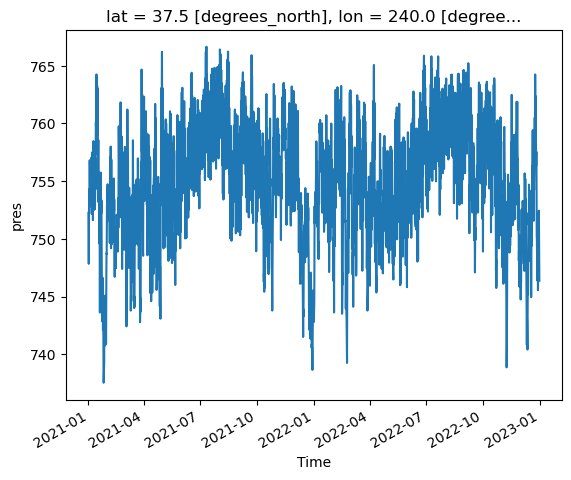

In [22]:
P2.pres.plot()

### Compare to Barologger Data
**Analyst TODO**: Plot available any available Barologger data together with the reanalysis data. Verify the time series resemble one another. 

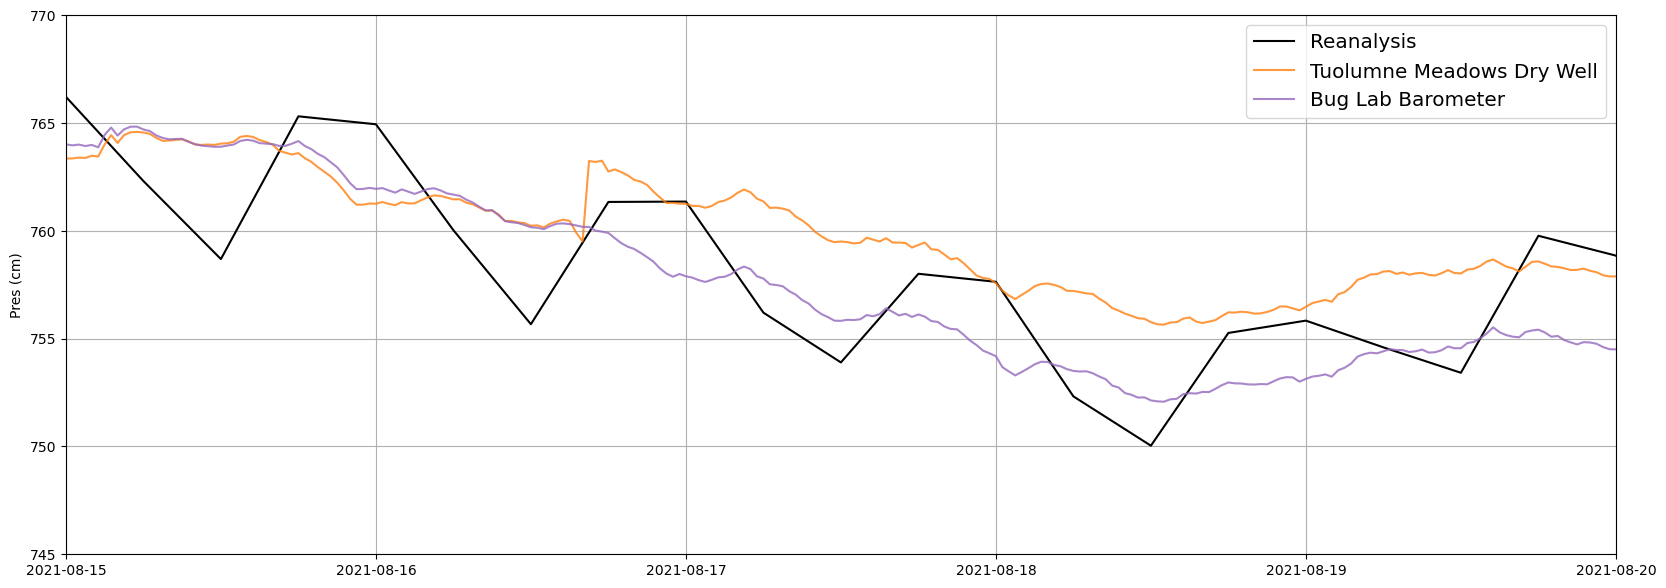

In [23]:
fig, ax = plt.subplots(figsize=((20,7)))
ax.plot(P2['time'],P2['pres'],c='black',label='Reanalysis')
ax.plot(baro_sample1_df['baro_cm'],alpha=0.8,label='Tuolumne Meadows Dry Well',c='C1')
ax.plot(baro_sample3_df['baro_cm'],alpha=0.8,label='Bug Lab Barometer',c='C4')
plt.xlim(pd.to_datetime("08/15/2021"),pd.to_datetime("08/20/2021"))
plt.ylim(745,770)
plt.ylabel("Pres (cm)")
plt.legend(fontsize='x-large')
plt.grid()

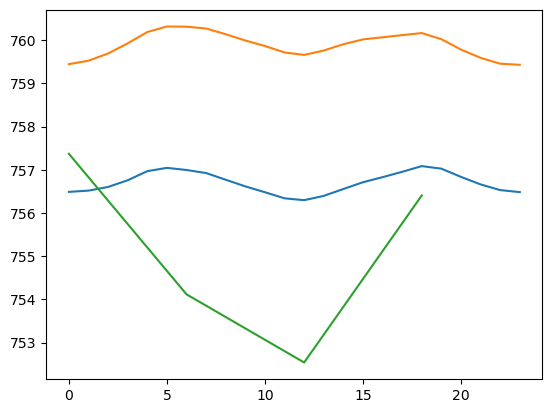

In [38]:
plt.plot(baro_sample3_df.groupby(baro_sample3_df.index.hour).mean()['baro_cm'])
plt.plot(baro_sample1_df.groupby(baro_sample1_df.index.hour).mean()['baro_cm'])

#P2 = P2.to_dataframe()
plt.plot(P2.groupby(P2.index.hour).mean()['pres'])

### Save Data
**Analyst TODO**: Nothing

In [ ]:
#recommend changing template code to the following:
#print(span[:2]+"."+span[3:])

In [ ]:
P2.to_netcdf(f'../data/ncar_reanalysis/hypso_pres.sfc.21.22.nc')

In [26]:
T.to_netcdf(f'../data/ncar_reanalysis/air.sig995.21.22.nc')